In [3]:
import importlib
import cv2
import numpy as np
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from utils import EyeStateModel, Preprocessing 
import matplotlib.pyplot as plt

2


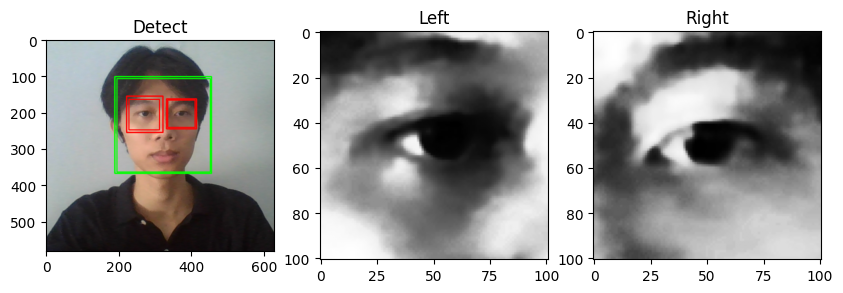

In [4]:
pre = Preprocessing(img_size=(101, 101))

base_dir = os.getcwd()
img_path = os.path.join(base_dir, "asset", "mhiu_open_eyes.jpg")

image_data = cv2.imread(img_path) 

if image_data is None:
    print(f"Lỗi: Không thể đọc được ảnh từ đường dẫn: {img_path}")
else:
    img, res = pre.preprocess_and_visualize(image_data) 
    print(len(res))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Detect")
    plt.imshow(img_rgb) 

    plt.subplot(1, 3, 2)
    plt.title("Left")
    plt.imshow(res[0], cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Right")
    plt.imshow(res[1], cmap='gray')
    plt.show()

In [5]:
model = EyeStateModel()

model.load("eye_model.h5")

d:\BTL_Python_Tr_Hieu\BTLPython\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\BTL_Python_Tr_Hieu\BTLPython\.venv\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model loaded from eye_model.h5


In [6]:
print(res[0].shape)

(101, 101, 1)


In [7]:
label_1, _ = model.predict(res[0])
label_2, _ = model.predict(res[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Dự đoán: Open (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Dự đoán: Open (1.00)
